### Set up

In [1]:
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torchmetrics
import torch.nn.functional as F

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load dataset

In [3]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [4]:
train_and_valid_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)

In [5]:
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

In [6]:
batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)

### Model - Image Classifier

In [7]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(nn.Flatten(), nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
                                 nn.Linear(n_hidden1, n_hidden2), nn.ReLU(), nn.Linear(n_hidden2, n_classes))

    def forward(self, X):
        return self.mlp(X)

In [8]:
torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10).to(device)
model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [9]:
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
learning_rate = 0.1
n_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [10]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs):
    model.train()
    losses = []
    val_losses = []
    accuracies = []
    val_accuracies = []
    for epoch in range(n_epochs):
        total_loss = 0.
        total_acc = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            total_acc += accuracy(y_pred, y_batch).item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        train_accuracy = total_acc / len(train_loader)
        x_val, y_val = next(iter(valid_loader))
        y_val_pred = model(x_val.to(device))
        val_loss = criterion(y_val_pred, y_val.to(device))
        val_acc = accuracy(y_val_pred, y_val.to(device)).item()
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        accuracies.append(train_accuracy)
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}, Train Accuracy: {train_accuracy}, Validation Accuracy: {val_acc}")
    return losses, val_losses, accuracies, val_accuracies

In [11]:
train_loss, val_loss, train_acc, val_acc = train(model, optimizer, xentropy, train_loader, valid_loader, n_epochs)

Epoch 1/10, Loss: 1.0948, Validation Loss: 0.7892679572105408, Train Accuracy: 0.636206664595493, Validation Accuracy: 0.67578125
Epoch 2/10, Loss: 0.6035, Validation Loss: 0.6066993474960327, Train Accuracy: 0.7834033162094826, Validation Accuracy: 0.8046875
Epoch 3/10, Loss: 0.5156, Validation Loss: 0.6781506538391113, Train Accuracy: 0.8169142980908238, Validation Accuracy: 0.79296875
Epoch 4/10, Loss: 0.4707, Validation Loss: 0.6566370129585266, Train Accuracy: 0.8321496824885524, Validation Accuracy: 0.8046875
Epoch 5/10, Loss: 0.4401, Validation Loss: 0.5313574075698853, Train Accuracy: 0.8430885281673698, Validation Accuracy: 0.82421875
Epoch 6/10, Loss: 0.4171, Validation Loss: 0.5392155647277832, Train Accuracy: 0.8514299364977105, Validation Accuracy: 0.83984375
Epoch 7/10, Loss: 0.4019, Validation Loss: 0.4930056035518646, Train Accuracy: 0.8567735250606093, Validation Accuracy: 0.83203125
Epoch 8/10, Loss: 0.3859, Validation Loss: 0.47088176012039185, Train Accuracy: 0.8609

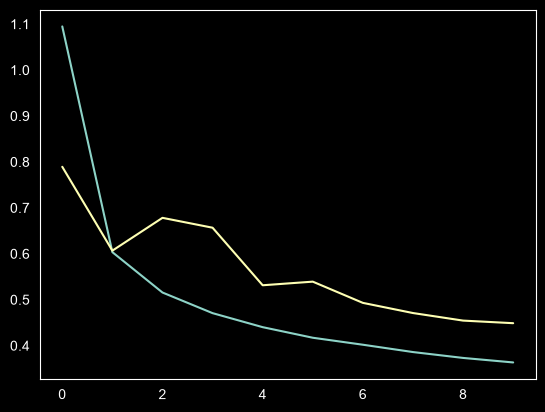

In [12]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()

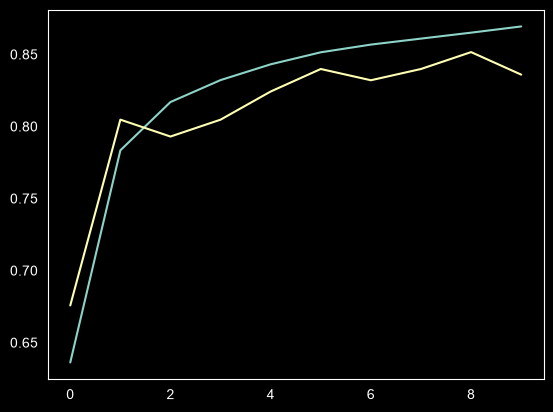

In [13]:
plt.plot(list(range(n_epochs)), train_acc)
plt.plot(list(range(n_epochs)), val_acc)
plt.grid()
plt.show()

### Evaluate

In [14]:
with torch.no_grad():
    x_test, y_test = next(iter(test_loader))
    y_test_pred = model(x_test.to(device))
    loss_test = xentropy(y_test_pred, y_test.to(device))
loss_test

tensor(0.3703, device='cuda:0')

In [15]:
accuracy(y_test_pred, y_test.to(device)).item()

0.87109375

In [16]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
    y_pred = y_pred_logits.argmax(dim=1) # index of the largest logit
    print(y_pred)
    print([train_and_valid_data.classes[index] for index in y_pred])

tensor([7, 4, 2], device='cuda:0')
['Sneaker', 'Coat', 'Pullover']


In [17]:
y_pred_logits

tensor([[ -2.3122,  -2.0120,  -2.8335,  -1.2814,  -3.0162,   3.7888,  -3.0836,
           7.4046,   1.5892,   3.4224],
        [ -0.4035,  -0.1391,   6.6429,   0.9992,  10.5448,  -5.8006,   4.9634,
          -7.9855,   1.4417, -10.4091],
        [  1.3193,  -2.5898,   6.5685,   2.3316,   5.0008,  -4.4960,   5.2664,
          -7.1320,   2.2621,  -7.2964]], device='cuda:0')

In [18]:
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0260, 0.0000, 0.9530, 0.0030,
         0.0180],
        [0.0000, 0.0000, 0.0200, 0.0000, 0.9760, 0.0000, 0.0040, 0.0000, 0.0000,
         0.0000],
        [0.0030, 0.0000, 0.6610, 0.0100, 0.1380, 0.0000, 0.1800, 0.0000, 0.0090,
         0.0000]], device='cuda:0')

In [19]:
X = X_new.to("cpu")
y = list(y_pred.to("cpu"))

In [20]:
y_top3_logits, y_top3_indices = torch.topk(y_pred_logits, k=3, dim=1)
y_top3_probas = F.softmax(y_top3_logits, dim=1)
y_top3_probas.round(decimals=3)

tensor([[0.9560, 0.0260, 0.0180],
        [0.9770, 0.0200, 0.0040],
        [0.6750, 0.1840, 0.1410]], device='cuda:0')

In [21]:
y_top3_indices

tensor([[7, 5, 9],
        [4, 2, 6],
        [2, 6, 4]], device='cuda:0')

### Hyper param tuning

In [22]:
import optuna

In [23]:
def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 1e-1, log=True)
    n_hidden1 = trial.suggest_int("n_hidden1", 10, 300)
    n_hidden2 = trial.suggest_int("n_hidden2", 10, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    train_loss, val_loss, train_acc, val_acc = train(model, optimizer, xentropy, train_loader, valid_loader, n_epochs)
    return val_acc[-1]

In [24]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=11)

[I 2026-09-26 03:52:43,518] A new study created in memory with name: no-name-d3d97074-d37b-4e05-9b1e-0c8e67891d9c


Epoch 1/10, Loss: 2.3050, Validation Loss: 2.304063081741333, Train Accuracy: 0.16385995371397152, Validation Accuracy: 0.14453125
Epoch 2/10, Loss: 2.3032, Validation Loss: 2.3022830486297607, Train Accuracy: 0.17252637813257615, Validation Accuracy: 0.15625
Epoch 3/10, Loss: 2.3014, Validation Loss: 2.300509452819824, Train Accuracy: 0.18085096360639083, Validation Accuracy: 0.1640625
Epoch 4/10, Loss: 2.2997, Validation Loss: 2.298752546310425, Train Accuracy: 0.18725842486980349, Validation Accuracy: 0.17578125
Epoch 5/10, Loss: 2.2979, Validation Loss: 2.297010660171509, Train Accuracy: 0.19318138998608256, Validation Accuracy: 0.1796875
Epoch 6/10, Loss: 2.2962, Validation Loss: 2.2952723503112793, Train Accuracy: 0.19967565675114476, Validation Accuracy: 0.19140625
Epoch 7/10, Loss: 2.2945, Validation Loss: 2.2935402393341064, Train Accuracy: 0.20706960600475932, Validation Accuracy: 0.1953125
Epoch 8/10, Loss: 2.2928, Validation Loss: 2.291811466217041, Train Accuracy: 0.214058

[I 2026-09-26 03:53:14,607] Trial 0 finished with value: 0.21875 and parameters: {'learning_rate': 7.459343285726558e-05, 'n_hidden1': 286, 'n_hidden2': 223}. Best is trial 0 with value: 0.21875.


Epoch 10/10, Loss: 2.2893, Validation Loss: 2.2883617877960205, Train Accuracy: 0.22652481697326482, Validation Accuracy: 0.21875
Epoch 1/10, Loss: 2.2964, Validation Loss: 2.283968448638916, Train Accuracy: 0.13223043174244636, Validation Accuracy: 0.1875
Epoch 2/10, Loss: 2.2798, Validation Loss: 2.26867938041687, Train Accuracy: 0.2183798988198125, Validation Accuracy: 0.2578125
Epoch 3/10, Loss: 2.2636, Validation Loss: 2.2531299591064453, Train Accuracy: 0.25323737624079684, Validation Accuracy: 0.2421875
Epoch 4/10, Loss: 2.2467, Validation Loss: 2.2360599040985107, Train Accuracy: 0.254517926310384, Validation Accuracy: 0.24609375
Epoch 5/10, Loss: 2.2282, Validation Loss: 2.2169673442840576, Train Accuracy: 0.24865552325581394, Validation Accuracy: 0.23828125
Epoch 6/10, Loss: 2.2072, Validation Loss: 2.1953125, Train Accuracy: 0.24535960374876511, Validation Accuracy: 0.2421875
Epoch 7/10, Loss: 2.1829, Validation Loss: 2.170215606689453, Train Accuracy: 0.24979207044424012, V

[I 2026-09-26 03:53:45,991] Trial 1 finished with value: 0.3515625 and parameters: {'learning_rate': 0.0009846738873614568, 'n_hidden1': 55, 'n_hidden2': 55}. Best is trial 1 with value: 0.3515625.


...

Epoch 10/10, Loss: 0.5421, Validation Loss: 0.6361632347106934, Train Accuracy: 0.8116265610206959, Validation Accuracy: 0.7890625
Epoch 1/10, Loss: 1.1927, Validation Loss: 0.8899832963943481, Train Accuracy: 0.6003916343977285, Validation Accuracy: 0.62890625
Epoch 2/10, Loss: 0.6477, Validation Loss: 0.695720911026001, Train Accuracy: 0.7684283483860105, Validation Accuracy: 0.7578125
Epoch 3/10, Loss: 0.5546, Validation Loss: 0.6017553806304932, Train Accuracy: 0.8027979651162791, Validation Accuracy: 0.8046875
Epoch 4/10, Loss: 0.5077, Validation Loss: 0.5724972486495972, Train Accuracy: 0.8203367247137913, Validation Accuracy: 0.828125
Epoch 5/10, Loss: 0.4751, Validation Loss: 0.5368954539299011, Train Accuracy: 0.8320803725442221, Validation Accuracy: 0.82421875
Epoch 6/10, Loss: 0.4511, Validation Loss: 0.5774197578430176, Train Accuracy: 0.8397946274557779, Validation Accuracy: 0.81640625
Epoch 7/10, Loss: 0.4313, Validation Loss: 0.5157235860824585, Train Accuracy: 0.8471340

[I 2026-09-26 04:28:10,648] Trial 98 finished with value: 0.83203125 and parameters: {'learning_rate': 0.07299277483362585, 'n_hidden1': 96, 'n_hidden2': 44}. Best is trial 10 with value: 0.84375.


Epoch 10/10, Loss: 0.3937, Validation Loss: 0.48987850546836853, Train Accuracy: 0.8594012435092483, Validation Accuracy: 0.83203125
Epoch 1/10, Loss: 1.4883, Validation Loss: 0.9518030881881714, Train Accuracy: 0.4829948588859203, Validation Accuracy: 0.6171875
Epoch 2/10, Loss: 0.7634, Validation Loss: 0.7708719372749329, Train Accuracy: 0.718490929104561, Validation Accuracy: 0.7109375
Epoch 3/10, Loss: 0.6471, Validation Loss: 0.6863936185836792, Train Accuracy: 0.7683132806489634, Validation Accuracy: 0.765625
Epoch 4/10, Loss: 0.5828, Validation Loss: 0.6522950530052185, Train Accuracy: 0.7944478090419326, Validation Accuracy: 0.77734375
Epoch 5/10, Loss: 0.5410, Validation Loss: 0.5918405055999756, Train Accuracy: 0.8108257967372273, Validation Accuracy: 0.81640625
Epoch 6/10, Loss: 0.5143, Validation Loss: 0.6195454597473145, Train Accuracy: 0.8195534561955652, Validation Accuracy: 0.78125
Epoch 7/10, Loss: 0.4913, Validation Loss: 0.5920330882072449, Train Accuracy: 0.82662979

[I 2026-09-26 04:28:22,647] Trial 99 finished with value: 0.8359375 and parameters: {'learning_rate': 0.039120835734498476, 'n_hidden1': 121, 'n_hidden2': 40}. Best is trial 10 with value: 0.84375.


Epoch 10/10, Loss: 0.4532, Validation Loss: 0.5480372905731201, Train Accuracy: 0.8406465330789256, Validation Accuracy: 0.8359375


In [25]:
study.best_params

{'learning_rate': 0.0702186372718365, 'n_hidden1': 21, 'n_hidden2': 95}

In [26]:
study.best_value

0.84375